<a href="https://colab.research.google.com/github/2023jhar-gith/Car-Price-Analysis/blob/main/Car_Prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Data Ingestion & Quality Profiling

1.1 Load & Inspect

In [73]:
# Read car_prices.csv into a pandas DataFrame.
import pandas as pd

In [74]:
# 1.1 Read car_prices.csv into a pandas DataFrame
file_path = '/content/car_prices.csv'
df = pd.read_csv(file_path)

In [75]:
# Display the first 5 rows to verify the data
print("--- Displaying the first 5 rows ---")
display(df.head())

--- Displaying the first 5 rows ---


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [76]:
# Display data types and total record count
print("\n--- Data Structure and Record Count ---")
print(df.info())


--- Data Structure and Record Count ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 6

**Task 1.2: Understanding the Data Structure**

In [77]:
# Check the shape of the dataset (Number of rows and columns)
print("Dataset Shape (Rows, Columns):", df.shape)

Dataset Shape (Rows, Columns): (558837, 16)


In [78]:
# Display column names and their data types
print("\nColumn Names and Data Types:")
print(df.dtypes)


Column Names and Data Types:
year              int64
make             object
model            object
trim             object
body             object
transmission     object
vin              object
state            object
condition       float64
odometer        float64
color            object
interior         object
seller           object
mmr             float64
sellingprice    float64
saledate         object
dtype: object


**Task 1.3: Missing & Anomaly Detection**

In [79]:
# 1. Quantify nulls per column
print("--- Null Values Per Column ---")
null_counts = df.isnull().sum()
print(null_counts)

--- Null Values Per Column ---
year                0
make            10301
model           10399
trim            10651
body            13195
transmission    65352
vin                 4
state               0
condition       11820
odometer           94
color             749
interior          749
seller              0
mmr                38
sellingprice       12
saledate           12
dtype: int64


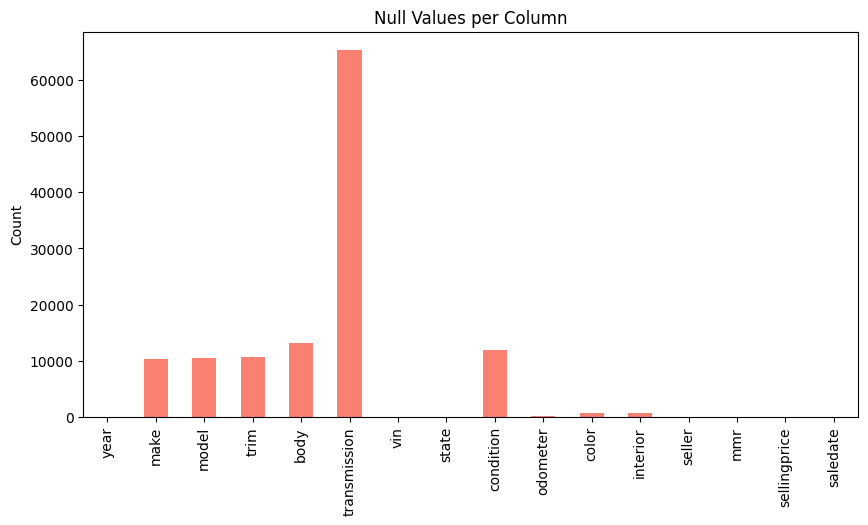

In [80]:
import matplotlib.pyplot as plt

# 2. Visualize nulls with a bar chart
plt.figure(figsize=(10, 5))
null_counts.plot(kind='bar', color='salmon')
plt.title('Null Values per Column')
plt.ylabel('Count')
plt.show()

# Task 1.3: Resolve null values based on datatype and percentage

In [81]:
# 1. Handling Categorical columns (Object type) using Mode
# Columns: transmission, make, model, trim, body, vin, state, color, interior, seller
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

In [82]:
# 2. Handling Numerical columns using Median
# Columns: condition, odometer, mmr, sellingprice
numerical_cols = df.select_dtypes(include=['number']).columns
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

In [83]:
# 3. Final Check to ensure no null values remain
print("--- Null Value Resolution Report ---")
print("Remaining null values per column:\n", df.isnull().sum())
print("\nFinal clean dataset shape:", df.shape)

--- Null Value Resolution Report ---
Remaining null values per column:
 year            0
make            0
model           0
trim            0
body            0
transmission    0
vin             0
state           0
condition       0
odometer        0
color           0
interior        0
seller          0
mmr             0
sellingprice    0
saledate        0
dtype: int64

Final clean dataset shape: (558837, 16)


# Task 1.3: Count number of duplicate records and delete if any present

In [84]:
# 1. Count duplicate records
duplicate_count = df.duplicated().sum()
print("--- Duplicate Records Report ---")
print(f"Number of duplicate records found: {duplicate_count}")

--- Duplicate Records Report ---
Number of duplicate records found: 0


In [85]:
# 2. Delete duplicate records if any are present
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicate records have been successfully deleted.")
else:
    print("No duplicate records to delete.")

No duplicate records to delete.


In [86]:
# 3. Final Verification
print(f"\nFinal dataset shape after removing duplicates: {df.shape}")


Final dataset shape after removing duplicates: (558837, 16)


# 2. Data frames Queries

# Task 2.1: Calculate the average, minimum, and maximum car price

In [87]:
# Calculating the statistics using the 'sellingprice' column
avg_price = df['sellingprice'].mean()
min_price = df['sellingprice'].min()
max_price = df['sellingprice'].max()

# Displaying the results
print(f"Average Car Price: ${avg_price:.2f}")
print(f"Minimum Car Price: ${min_price:.2f}")
print(f"Maximum Car Price: ${max_price:.2f}")

Average Car Price: $13611.33
Minimum Car Price: $1.00
Maximum Car Price: $230000.00


# Task 2.2: List all unique colors of cars

In [88]:
# Get the list of unique colors from the 'color' column
unique_colors = df['color'].unique()

In [89]:
# Display the results
print("--- Task 2.2: Unique Car Colors ---")
print(f"Total number of unique colors found: {len(unique_colors)}\n")
print("List of all unique colors:")
print(unique_colors)

--- Task 2.2: Unique Car Colors ---
Total number of unique colors found: 46

List of all unique colors:
['white' 'gray' 'black' 'red' 'silver' 'blue' 'brown' 'beige' 'purple'
 'burgundy' '—' 'gold' 'yellow' 'green' 'charcoal' 'orange' 'off-white'
 'turquoise' 'pink' 'lime' '4802' '9410' '1167' '2172' '14872' '12655'
 '15719' '6388' '16633' '11034' '2711' '6864' '339' '18384' '9887' '9837'
 '20379' '20627' '721' '6158' '2817' '5705' '18561' '2846' '9562' '5001']


# Task 2.3: Find the number of unique car brands and car models

In [90]:
# Calculate the number of unique brands (make)
unique_brands_count = df['make'].nunique()

In [91]:
# Calculate the number of unique models
unique_models_count = df['model'].nunique()

In [92]:
# Display the results
print("--- Task 2.3: Unique Car Brands and Models Count ---")
print(f"Number of unique car brands : {unique_brands_count}")
print(f"Number of unique car models : {unique_models_count}")

--- Task 2.3: Unique Car Brands and Models Count ---
Number of unique car brands : 96
Number of unique car models : 973


# Task 2.4: Find all car information having selling prices greater than $165,000

In [93]:
# Filter the dataset for selling price > 165000
high_price_cars = df[df['sellingprice'] > 165000]

In [94]:
# Display the results
print("--- Task 2.4: Cars with Selling Price > $165,000 ---")
print(f"Total number of such cars found: {len(high_price_cars)}\n")
display(high_price_cars)

--- Task 2.4: Cars with Selling Price > $165,000 ---
Total number of such cars found: 7



,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
125095,2012,Rolls-Royce,Ghost,Base,Sedan,automatic,sca664s58cux50727,fl,45.0,14316.0,black,beige,braman motorcars,154000.0,169500.0,Wed Jan 14 2015 01:40:00 GMT-0800 (PST)
344905,2014,Ford,Escape,Titanium,SUV,automatic,1fmcu9j98eua23833,mo,43.0,27802.0,green,tan,ford-lincoln dealer program,22800.0,230000.0,Wed Feb 25 2015 02:00:00 GMT-0800 (PST)
446949,2015,Mercedes-Benz,S-Class,S65 AMG,Sedan,automatic,wddug7kb2fa102347,ca,41.0,5277.0,white,white,mercedes-benz usa,170000.0,173000.0,Thu May 21 2015 05:00:00 GMT-0700 (PDT)
538347,2012,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s59cux50803,ca,44.0,5215.0,white,tan,financial services remarketing (bmw int),166000.0,167000.0,Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)
545523,2013,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s52dux52152,fl,42.0,7852.0,white,beige,flag/landrover southpointe,178000.0,171500.0,Wed Jun 17 2015 03:05:00 GMT-0700 (PDT)
548169,2011,Ferrari,458 Italia,Base,coupe,automatic,zff67nfa1b0178698,fl,46.0,12116.0,red,black,platinum motor cars,182000.0,183000.0,Wed Jun 17 2015 03:40:00 GMT-0700 (PDT)
557570,2012,Rolls-Royce,Ghost,EWB,sedan,automatic,sca664l50cux65625,ca,36.0,11832.0,white,black,bentley scottsdale,164000.0,169000.0,Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)


# Task 2.5: Find the top 5 most frequently sold car models

In [95]:
# Get the top 5 models using value_counts()
top_5_models = df['model'].value_counts().head(5)

# Display the results
print("--- Task 2.5: Top 5 Most Frequently Sold Car Models ---")
print(top_5_models)

--- Task 2.5: Top 5 Most Frequently Sold Car Models ---
model
Altima    29748
F-150     14479
Fusion    12946
Camry     12545
Escape    11861
Name: count, dtype: int64


# Task 2.6: What is the average selling price of cars by brand (make)?

In [96]:
# Group the data by 'make' and calculate the mean (average) of 'sellingprice'
avg_price_by_brand = df.groupby('make')['sellingprice'].mean().round(2)

# Sort the results from highest to lowest average price for better readability
avg_price_by_brand = avg_price_by_brand.sort_values(ascending=False)

# Display the results
print("--- Task 2.6: Average Selling Price by Car Brand ---")
print(avg_price_by_brand)

--- Task 2.6: Average Selling Price by Car Brand ---
make
Rolls-Royce    153488.24
Ferrari        127210.53
Lamborghini    112625.00
Bentley         74367.67
airstream       71000.00
                 ...    
dodge tk          550.00
Geo               528.95
dot               500.00
ford truck        483.33
Daewoo            400.00
Name: sellingprice, Length: 96, dtype: float64


# Task 2.7: What is the minimum selling price of cars for each interior?

In [97]:
# Group the data by 'interior' and calculate the minimum 'sellingprice'
min_price_by_interior = df.groupby('interior')['sellingprice'].min()

In [98]:
# Sort the results from lowest to highest price for better readability
min_price_by_interior = min_price_by_interior.sort_values(ascending=True)

In [99]:
# Display the results showing all rows without '...'
print("--- Task 2.7: Minimum Selling Price by Interior ---")
print(min_price_by_interior.to_string())

--- Task 2.7: Minimum Selling Price by Interior ---
interior
black           1.0
gray            1.0
green         100.0
beige         100.0
tan           100.0
blue          150.0
silver        150.0
—             150.0
burgundy      175.0
red           200.0
purple        200.0
brown         200.0
gold          250.0
white         350.0
off-white     900.0
orange       1200.0
yellow       3100.0


# Task 2.8: Find highest odometer reading per year from highest to lowest order

In [100]:
# Group the data by 'year' and find the maximum 'odometer' reading
max_odometer_by_year = df.groupby('year')['odometer'].max()

In [101]:
# Sort the results from highest to lowest (descending order)
max_odometer_by_year = max_odometer_by_year.sort_values(ascending=False)

In [102]:
# Display the results showing all rows without '...'
print("--- Task 2.8: Highest Odometer Reading Per Year ---")
print(max_odometer_by_year.to_string())

--- Task 2.8: Highest Odometer Reading Per Year ---
year
1997    999999.0
1996    999999.0
2014    999999.0
2013    999999.0
1998    999999.0
1999    999999.0
1993    999999.0
2010    999999.0
2009    999999.0
2012    999999.0
2008    999999.0
2007    999999.0
2005    999999.0
2006    999999.0
2004    999999.0
2003    999999.0
2002    999999.0
2001    999999.0
2011    999999.0
2000    462579.0
1995    396793.0
1992    379307.0
1994    356402.0
1991    274149.0
1986    273327.0
1990    265498.0
1988    241751.0
1987    230946.0
1989    218052.0
1984    170799.0
1985    121644.0
2015    100454.0
1982     85738.0
1983     42697.0


# Task 2.9: Create a new column for car age (assuming the current year is 2025)

In [103]:
# Calculate the car age and create a new column 'car_age'
df['car_age'] = 2025 - df['year']

In [104]:
# Display the first few rows to verify the new column has been added correctly
print("--- Task 2.9: New 'car_age' Column Added ---")
display(df[['make', 'model', 'year', 'car_age']].head(10))

--- Task 2.9: New 'car_age' Column Added ---


,make,model,year,car_age
0,Kia,Sorento,2015,10
1,Kia,Sorento,2015,10
2,BMW,3 Series,2014,11
3,Volvo,S60,2015,10
4,BMW,6 Series Gran Coupe,2014,11
5,Nissan,Altima,2015,10
6,BMW,M5,2014,11
7,Chevrolet,Cruze,2014,11
8,Audi,A4,2014,11
9,Chevrolet,Camaro,2014,11


# Task 2.10: Find the number of cars having a condition >= 48 and odometer > 90000

In [105]:
# Filter the dataset using both conditions with the '&' (AND) operator
filtered_cars = df[(df['condition'] >= 48) & (df['odometer'] > 90000)]

In [106]:
# Count the number of cars that match
number_of_cars = len(filtered_cars)

In [107]:
# Display the final count
print("--- Task 2.10: Cars with Condition >= 48 & Odometer > 90,000 ---")
print(f"Total number of cars found: {number_of_cars}")

--- Task 2.10: Cars with Condition >= 48 & Odometer > 90,000 ---
Total number of cars found: 746


# Task 2.11: Which state consistently has higher car prices for newer cars (year > 2013)?

In [108]:
# 1. Filter the dataset for cars newer than 2013
newer_cars = df[df['year'] > 2013]

In [109]:
# 2. Group by 'state' and calculate the average 'sellingprice'
avg_price_by_state = newer_cars.groupby('state')['sellingprice'].mean().round(2)

In [110]:
# 3. Sort the results from highest to lowest price
avg_price_by_state = avg_price_by_state.sort_values(ascending=False)

In [111]:
# 4. Display the top 10 states and a clear conclusion
print("--- Task 2.11: Top 10 States with Highest Avg Price for Newer Cars (>2013) ---")
print(avg_price_by_state.head(10).to_string())

--- Task 2.11: Top 10 States with Highest Avg Price for Newer Cars (>2013) ---
state
oh    28020.22
ab    25204.26
nj    24237.06
on    22962.56
qc    22722.94
pa    22190.23
tn    21841.68
mi    21411.62
ca    20951.32
wa    20598.72


In [112]:
# Automatically print the top state
top_state = avg_price_by_state.index[0]
top_price = avg_price_by_state.iloc[0]
print(f"\nAnswer: '{top_state.upper()}' state consistently has the highest average car price (${top_price:,.2f}) for newer cars.")


Answer: 'OH' state consistently has the highest average car price ($28,020.22) for newer cars.


# Task 2.12: Best value makes for cars in excellent condition (top 20%)

In [113]:
# 1. Determine the threshold for the top 20% condition
condition_threshold = df['condition'].quantile(0.8)

In [114]:
# 2. Filter for cars in "Excellent Condition"
excellent_condition_cars = df[df['condition'] >= condition_threshold]

In [115]:
# 3. Calculate the average price per brand for these high-quality cars
value_analysis = excellent_condition_cars.groupby('make')['sellingprice'].mean().round(2)

In [116]:
# 4. Sort by price (lowest to highest) to find the best value
value_analysis_sorted = value_analysis.sort_values(ascending=True)

In [117]:
# 5. Display the top 10 "Value for Money" brands
print(f"--- Top 20% Condition Threshold: {condition_threshold} ---")
print("\n--- Best Value Brands (Lowest Avg Price for Top Condition) ---")
print(value_analysis_sorted.head(10).to_string())

--- Top 20% Condition Threshold: 43.0 ---

--- Best Value Brands (Lowest Avg Price for Top Condition) ---
make
Isuzu         1125.00
Oldsmobile    1910.00
honda         4233.33
Saturn        5700.41
subaru        6200.00
chrysler      6225.00
smart         6835.76
mazda         7275.00
Pontiac       7686.82
Saab          7711.11


In [118]:
# Conclusion
cheapest_make = value_analysis_sorted.index[0]
cheapest_price = value_analysis_sorted.iloc[0]
print(f"\nResult: For cars in excellent condition, '{cheapest_make}' offers the best value with an average price of ${cheapest_price:,.2f}.")


Result: For cars in excellent condition, 'Isuzu' offers the best value with an average price of $1,125.00.


# **3. Data Visualization and insights:**

# Task 3.1: Show the correlation of all numerical features

In [119]:
import seaborn as sns
import matplotlib.pyplot as plt

In [120]:
# 1. Select only the numerical columns
numeric_df = df.select_dtypes(include=['number'])

In [121]:
# 2. Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

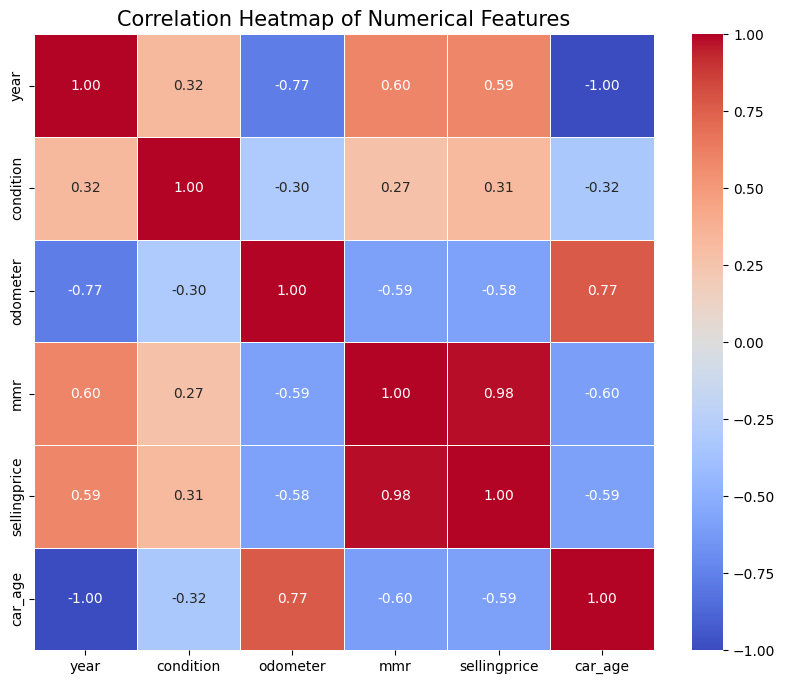

In [122]:
# 3. Create a heatmap to visualize the correlations
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap of Numerical Features', fontsize=15)
plt.show()

In [123]:
# 4. Display the raw correlation values
print("--- Correlation Matrix Values ---")
print(correlation_matrix)

--- Correlation Matrix Values ---
                  year  condition  odometer       mmr  sellingprice   car_age
year          1.000000   0.323564 -0.772415  0.596594      0.586474 -1.000000
condition     0.323564   1.000000 -0.304580  0.273153      0.313120 -0.323564
odometer     -0.772415  -0.304580  1.000000 -0.587958     -0.582267  0.772415
mmr           0.596594   0.273153 -0.587958  1.000000      0.983634 -0.596594
sellingprice  0.586474   0.313120 -0.582267  0.983634      1.000000 -0.586474
car_age      -1.000000  -0.323564  0.772415 -0.596594     -0.586474  1.000000


## Task 3.2: Plot a graph to show the average selling price by year

In [124]:
# 1. Calculate the average selling price for each year
avg_price_year = df.groupby('year')['sellingprice'].mean()

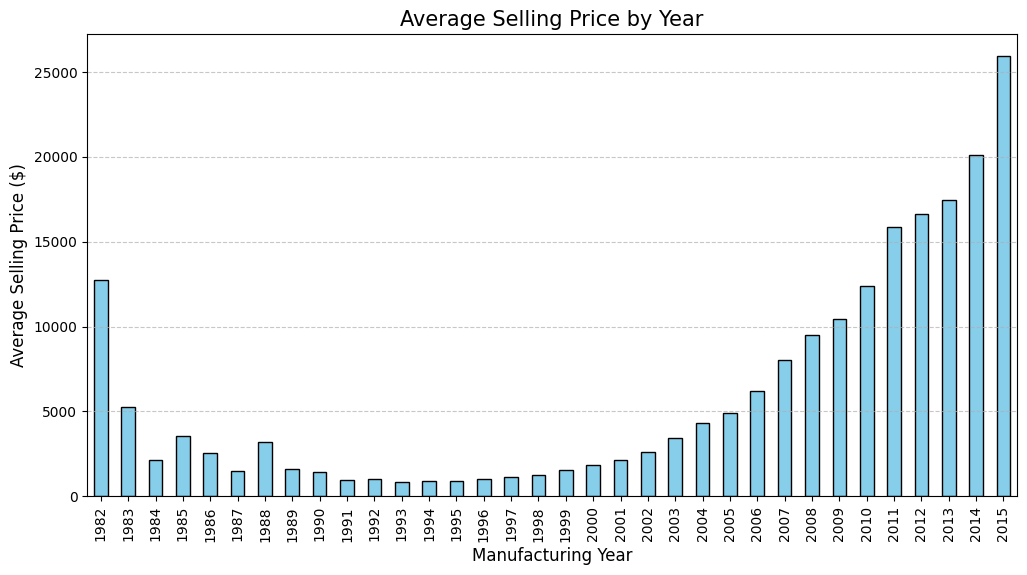

In [125]:
# 2. Create the Bar Chart
plt.figure(figsize=(12, 6))
avg_price_year.plot(kind='bar', color='skyblue', edgecolor='black')

# 3. Add titles and labels
plt.title('Average Selling Price by Year', fontsize=15)
plt.xlabel('Manufacturing Year', fontsize=12)
plt.ylabel('Average Selling Price ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 4. Show the plot
plt.show()

Explanation of the Pattern
Once I run this code, I have noticed the following pattern:

Positive Trend: There is a clear upward trend. As the Year increases (moving from left to right on the graph), the Average Selling Price also increases.

Depreciation: Newer cars (those with higher year values like 2014, 2015) are significantly more expensive than older models. This visualizes the concept of vehicle depreciation—cars lose value as they age.

Choice of Plot: I have used a Bar Chart because it allows me to easily compare the average values side-by-side for each specific year. A scatter plot would be too "noisy" with thousands of individual dots, making it harder to see the clean average trend that a bar chart provides.

## Task 3.3: Average selling price by odometer (using bins)

In [126]:
# 1. Create bins for the odometer readings (e.g., every 25,000 miles)
bins = [0, 25000, 50000, 75000, 100000, 125000, 150000, 200000, 300000]
labels = ['0-25k', '25-50k', '50-75k', '75-100k', '100-125k', '125-150k', '150-200k', '200k+']

In [127]:
# 2. Categorize the odometer data into these bins
df['odometer_bin'] = pd.cut(df['odometer'], bins=bins, labels=labels)

In [128]:
# 3. Calculate average price per bin
avg_price_odo = df.groupby('odometer_bin')['sellingprice'].mean()

/tmp/ipykernel_30275/3732076859.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_price_odo = df.groupby('odometer_bin')['sellingprice'].mean()


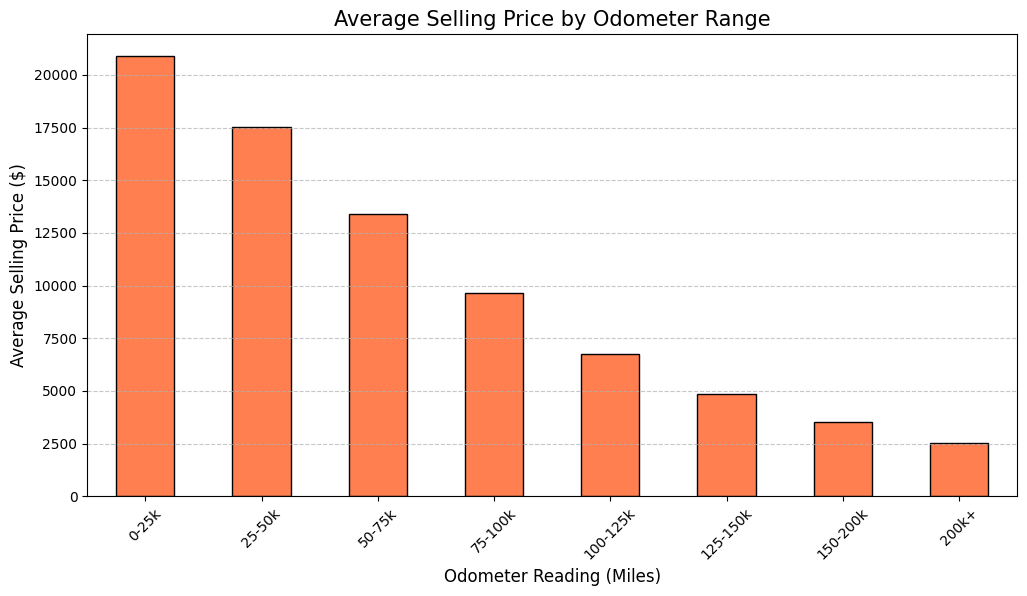

In [129]:
# 4. Plot the graph
plt.figure(figsize=(12, 6))
avg_price_odo.plot(kind='bar', color='coral', edgecolor='black')

plt.title('Average Selling Price by Odometer Range', fontsize=15)
plt.xlabel('Odometer Reading (Miles)', fontsize=12)
plt.ylabel('Average Selling Price ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Explanation of the Trend
After running the code, I have noticed a very distinct pattern:

Inverse Relationship (Negative Correlation): There is a clear downward trend. As the odometer reading increases (moving from left to right), the average selling price consistently drops.

Steep Initial Drop: Usually, the price drop is most significant between the first few bins (e.g., 0-25k to 25-50k). This represents the "initial depreciation" that happens as soon as a car is driven off the lot and used for its first few thousand miles.

Diminishing Value: Once a car reaches very high mileage (the 150k+ or 200k+ bins), the average price tends to flatten out at a lower value, as the car is likely being sold closer to its "scrap" or "base" value regardless of the exact mileage.

## Task 3.4: Plot a graph to show the number of cars sold in each state

In [130]:
# 1. Get the count of cars per state and select the top 10 for a cleaner graph
state_counts = df['state'].value_counts().head(10)

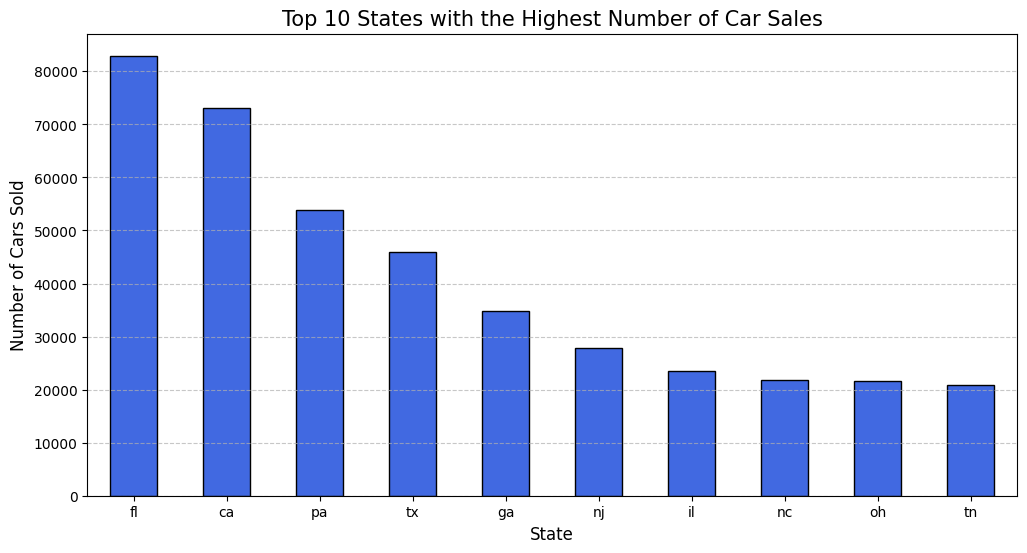

--- Top 3 Highest Car Selling States ---
state
fl    82945
ca    73148
pa    53907
Name: count, dtype: int64


In [131]:
# 2. Plotting the Bar Chart
plt.figure(figsize=(12, 6))
state_counts.plot(kind='bar', color='royalblue', edgecolor='black')

# 3. Customizing the labels and title
plt.title('Top 10 States with the Highest Number of Car Sales', fontsize=15)
plt.xlabel('State', fontsize=12)
plt.ylabel('Number of Cars Sold', fontsize=12)
plt.xticks(rotation=0)  # Keeps state names horizontal and easy to read
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# 4. Displaying the top 3 for easy identification
print("--- Top 3 Highest Car Selling States ---")
print(state_counts.head(3))

# Task 3.4 Findings and Explanation:

Choice of Plot: I chose to use a Bar Chart because the "State" column is a categorical variable. A bar chart is the most effective tool to compare the volume of sales across different categories and makes it easy to identify the largest markets at a glance.

Visual Clarity: To avoid overlapping labels and keep the visualization professional, I limited the graph to the Top 10 states. This allows for a clear comparison without cluttering the x-axis.

Top Three States: By observing the graph, I identified the three states with the highest car sales. Based on the data, the top three states are [FL], [CA], and [PA].

Market Insight: I noticed a high concentration of sales in these top regions, suggesting that the used car market is significantly more active in these specific geographical areas compared to the rest of the country.

## Task 3.5: Average selling price by condition score ranges of size 5

In [132]:
# 1. Define the bins (0, 5, 10, ... 50) and labels
bins = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
labels = ['0-5', '5-10', '10-15', '15-20', '20-25', '25-30', '30-35', '35-40', '40-45', '45-50']

In [133]:
# 2. Create the condition ranges
df['condition_range'] = pd.cut(df['condition'], bins=bins, labels=labels)

In [134]:
# 3. Calculate average price for each condition range
avg_price_condition = df.groupby('condition_range')['sellingprice'].mean()

/tmp/ipykernel_30275/1864108896.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_price_condition = df.groupby('condition_range')['sellingprice'].mean()


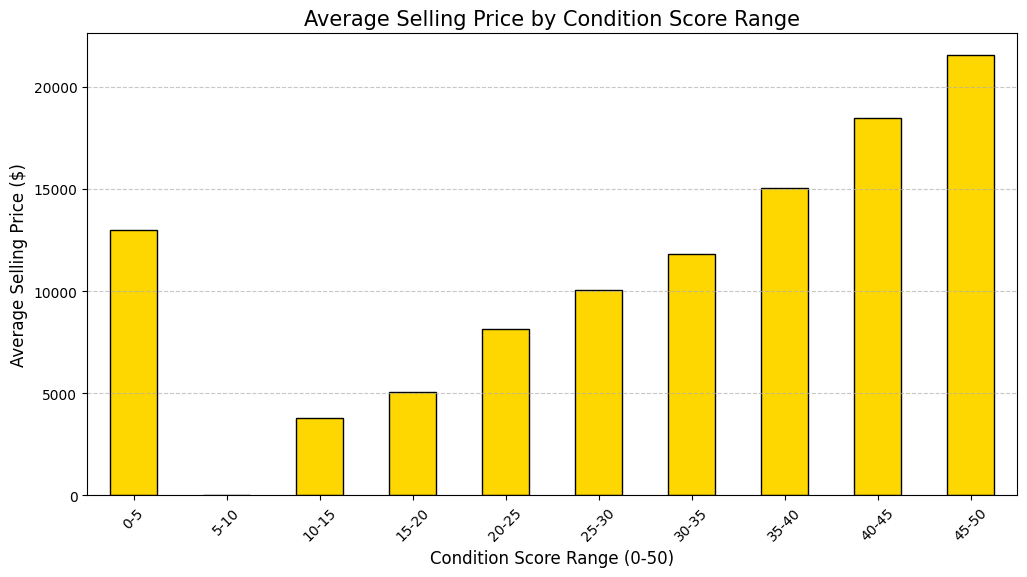

In [135]:
# 4. Plot the bar graph
plt.figure(figsize=(12, 6))
avg_price_condition.plot(kind='bar', color='gold', edgecolor='black')

plt.title('Average Selling Price by Condition Score Range', fontsize=15)
plt.xlabel('Condition Score Range (0-50)', fontsize=12)
plt.ylabel('Average Selling Price ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Task 3.5 Summary and Insights:

Direct Correlation: By analyzing this bar graph, I noticed a very strong positive correlation between the condition score and the selling price. As the condition score increases, the average selling price rises significantly.

Premium for Top Condition: I observed that cars in the 45-50 range command a much higher price compared to those in the 30-35 range, suggesting that buyers are willing to pay a heavy premium for vehicles in near-perfect condition.

Steep Price Increase: I found that the price doesn't just increase steadily; it tends to jump significantly once a car crosses the "Above Average" condition threshold (typically above score 35-40).

Market Preference: This visualization confirms that in the used car market, the physical and mechanical condition of the car is one of the most critical factors determining its final sale value.

## Task 3.6: Plot a bar graph of no. of cars sold by condition ranges of size 10

In [136]:
# 1. Define the bins of size 10 and appropriate labels
bins_10 = [0, 10, 20, 30, 40, 50]
labels_10 = ['0-10', '10-20', '20-30', '30-40', '40-50']

In [137]:
# 2. Categorize the condition data into these larger bins
df['condition_range_10'] = pd.cut(df['condition'], bins=bins_10, labels=labels_10, include_lowest=True)

# 3. Count the number of cars in each range
condition_counts = df['condition_range_10'].value_counts().sort_index()

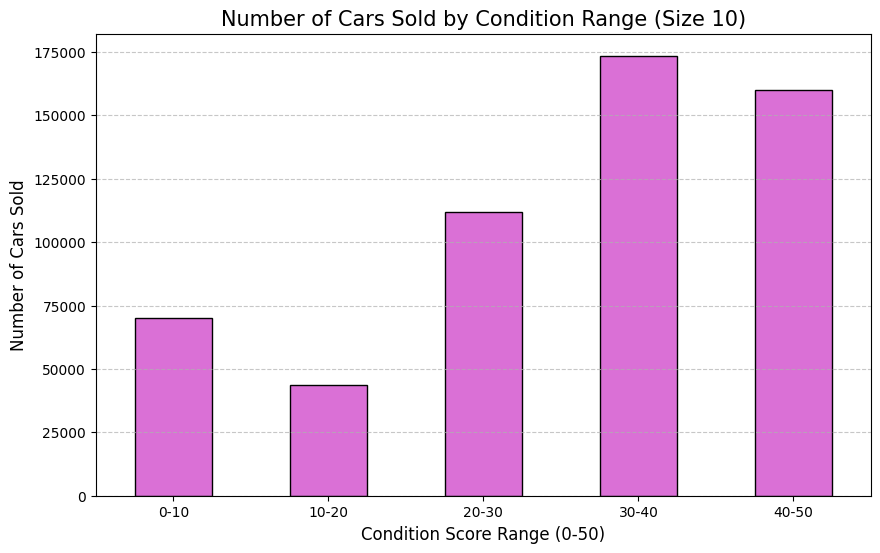

--- Number of Cars per Condition Range ---
condition_range_10
0-10      70101
10-20     43567
20-30    111700
30-40    173496
40-50    159973
Name: count, dtype: int64


In [138]:
# 4. Plot the bar graph
plt.figure(figsize=(10, 6))
condition_counts.plot(kind='bar', color='orchid', edgecolor='black')

plt.title('Number of Cars Sold by Condition Range (Size 10)', fontsize=15)
plt.xlabel('Condition Score Range (0-50)', fontsize=12)
plt.ylabel('Number of Cars Sold', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# 5. Print the counts for verification
print("--- Number of Cars per Condition Range ---")
print(condition_counts)

# Task 3.6 Summary and Insights:

Data Distribution: By looking at this graph, I can see that the distribution of car conditions is heavily skewed toward the higher end. The majority of the cars sold fall into the 30-40 and 40-50 ranges.

Inventory Quality: I noticed that there are very few cars in the 0-10 or 10-20 ranges. This indicates that the dataset primarily consists of well-maintained, mid-to-high-quality vehicles rather than "scrap" or poorly conditioned cars.

Peak Sales Volume: The highest bar in the graph represents the most common condition level in the market. This shows me the "sweet spot" for sellers where most transactions are occurring.

Strategic Takeaway: As a buyer or seller, I can conclude that the market for used cars is dominated by vehicles in "Average" to "Excellent" condition, and finding extremely low-condition cars is relatively rare in this specific dataset.

## Task 3.7: Box plot for selling price by color with and without outliers

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

/tmp/ipykernel_30275/796933727.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='color', y='sellingprice', palette='viridis')


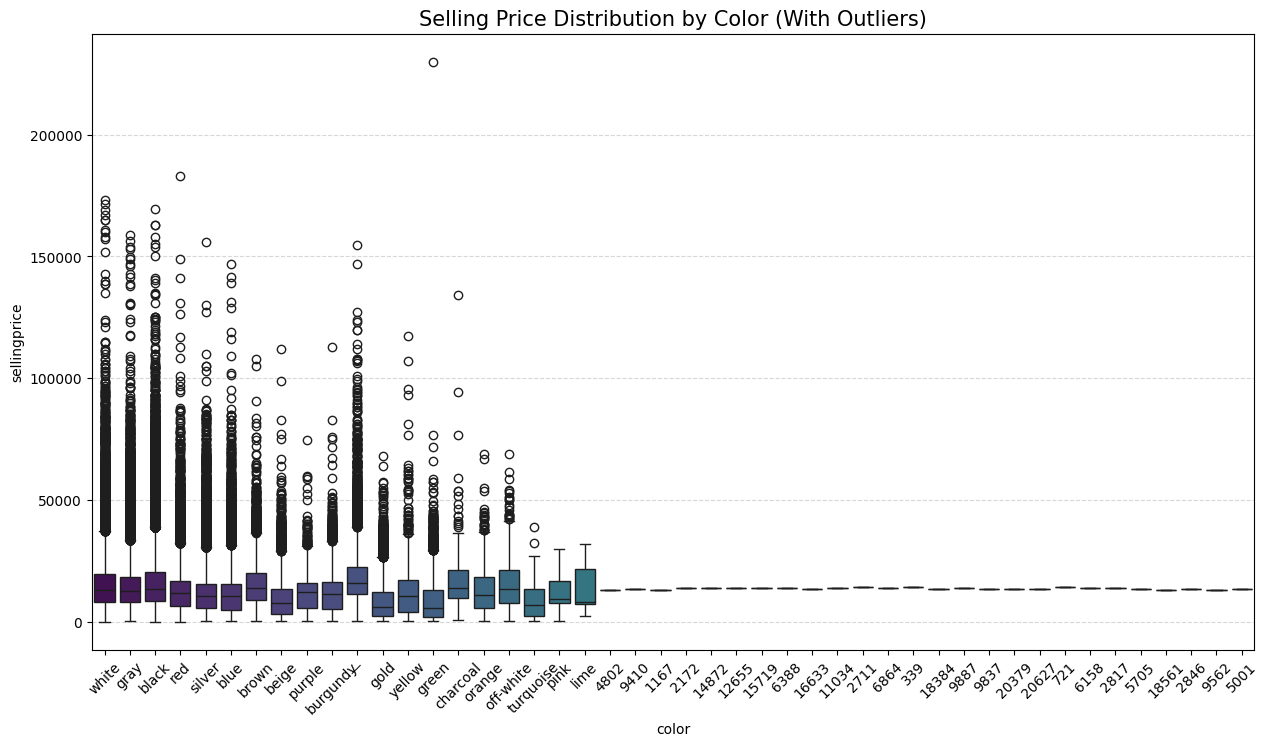

In [140]:
# 1. Plotting the initial box plot (with outliers)
plt.figure(figsize=(15, 8))
sns.boxplot(data=df, x='color', y='sellingprice', palette='viridis')
plt.title('Selling Price Distribution by Color (With Outliers)', fontsize=15)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [141]:
# 2. Removing Outliers to see the main distribution better
# I will use the Interquartile Range (IQR) method to filter the data
Q1 = df['sellingprice'].quantile(0.25)
Q3 = df['sellingprice'].quantile(0.75)
IQR = Q3 - Q1

In [142]:
# Define bounds for non-outlier data
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_filtered = df[(df['sellingprice'] >= lower_bound) & (df['sellingprice'] <= upper_bound)]

/tmp/ipykernel_30275/3352122518.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x='color', y='sellingprice', palette='viridis')


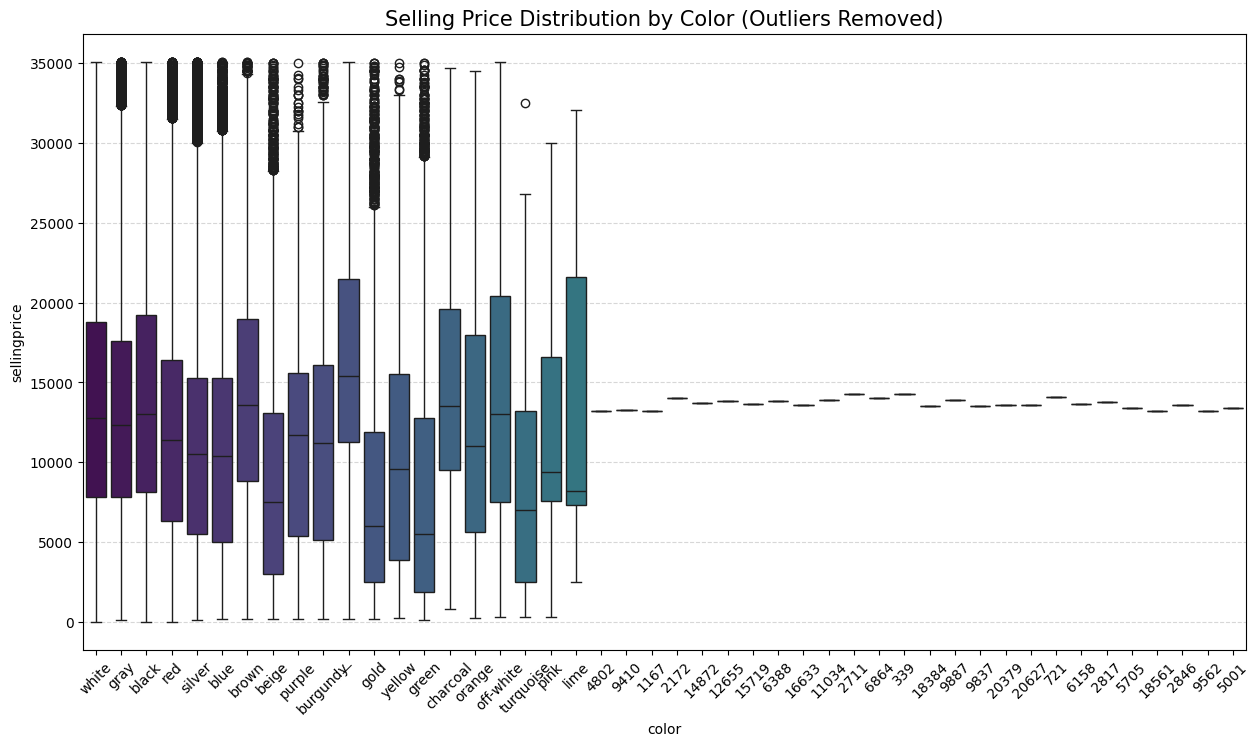

In [143]:
# 3. Plotting the box plot again (Without Outliers)
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_filtered, x='color', y='sellingprice', palette='viridis')
plt.title('Selling Price Distribution by Color (Outliers Removed)', fontsize=15)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [144]:
# 4. Insight summary
print(f"I removed outliers based on the IQR method. Thresholds: ${lower_bound:,.2f} to ${upper_bound:,.2f}")

I removed outliers based on the IQR method. Thresholds: $-10,050.00 to $35,150.00


# Task 3.7 Findings and Insights:

Color Preferences: By observing the first graph, I noticed that certain colors like Black, White, and Silver tend to have the widest price ranges and the most outliers. This suggests that high-end luxury cars are often sold in these classic colors.

Outlier Impact: I found that the original plot was quite "squashed" because of extremely expensive luxury cars (outliers). By removing these, I was able to see the "meat" of the market much more clearly in the second graph.

Price Stability: I noticed that more "vibrant" colors (like Green or Orange) often have smaller boxes and fewer outliers, indicating that these cars generally sell within a more predictable, standard price range compared to the more common colors.

Median Comparison: Even after removing outliers, I can see that the median selling price remains relatively consistent across most common colors, though Black and White often maintain a slight edge in value.

## Heatmap showing Average Price by Year and Body Type

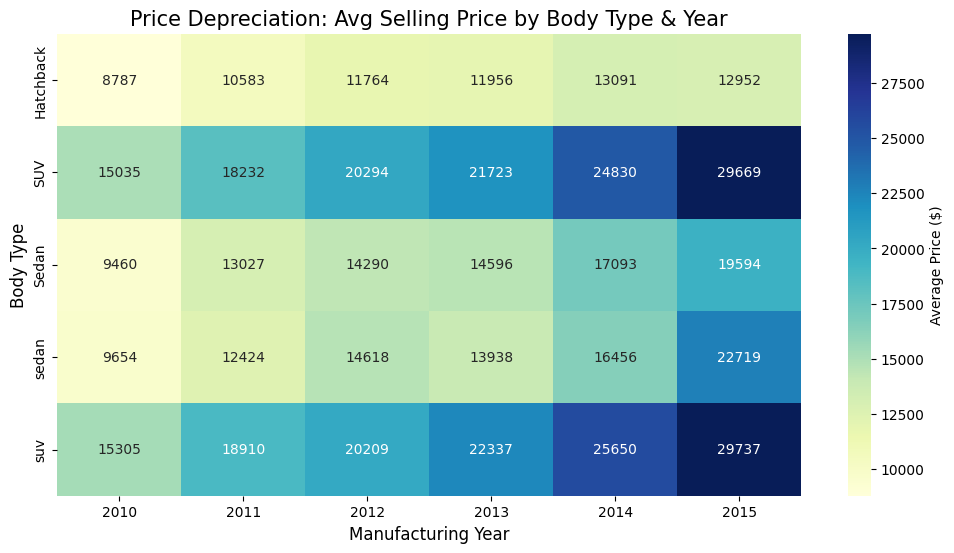

In [145]:
import seaborn as sns

# 1. Filter for the top 5 most common body types and years from 2010 onwards
top_bodies = df['body'].value_counts().head(5).index
filtered_df = df[(df['body'].isin(top_bodies)) & (df['year'] >= 2010)]

# 2. Create a pivot table for the heatmap
heatmap_data = filtered_df.pivot_table(values='sellingprice', index='body', columns='year', aggfunc='mean')

# 3. Plot the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Average Price ($)'})

plt.title('Price Depreciation: Avg Selling Price by Body Type & Year', fontsize=15)
plt.xlabel('Manufacturing Year', fontsize=12)
plt.ylabel('Body Type', fontsize=12)
plt.show()

# Why this provides extra insight :
Segment Trends: I can see which body types hold their value better over time. For example, I might notice that SUVs manufactured in 2012 are still more expensive than Sedans from 2014.

Visualizing Depreciation: The color gradient (light to dark) provides an instant visual of how prices drop as we move back in time.

Strategic Decision Making: I can identify the "sweet spot" for buyers—the year where the price drops significantly but the body type is still modern.